In [1]:
1

1

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [3]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
        emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = self.norm1(F.gelu(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(F.gelu(self.conv2(h)))
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        skip = self.conv(x, t_emb)
        return self.pool(skip), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x, t_emb)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
        super().__init__()

        self.time_proj = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )

        self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7

        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)

        self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
        self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28

        self.out = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        '''
        :x input [bs, C, H, W] - image
        :t 1d torch.LongTensor of timesteps
        '''
        t_emb = self.time_proj(t)

        x, skip1 = self.down1(x, t_emb)
        x, skip2 = self.down2(x, t_emb)

        x = self.bottleneck(x, t_emb)

        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)

        return self.out(x)

In [4]:
# Setup Device
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# MNIST Dataset (same transform as fft_process_fm: scale to [-1, 1])
train_dataset = torchvision.datasets.MNIST(
    root='.',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)
    ])
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [8]:
def fft_truncate(image, t):
    fft = torch.fft.fft2(image)
    shifted_fft = torch.fft.fftshift(fft, dim=(-2, -1))  # ← important: dim!
    
    H, W = image.shape[-2:]
    h_center, w_center = H // 2, W // 2

    h_low = max(0, h_center - t)
    h_high = min(H, h_center + t)
    w_low = max(0, w_center - t)
    w_high = min(W, w_center + t)
    
    # Zero out everything *outside* the central square
    mask = torch.zeros_like(shifted_fft, dtype=torch.bool)
    mask[..., h_low:h_high, w_low:w_high] = True
    shifted_fft = shifted_fft * mask  # or use where / masked_fill
    
    # Inverse
    unshifted_fft = torch.fft.ifftshift(shifted_fft, dim=(-2, -1))
    restored = torch.fft.ifft2(unshifted_fft).real
    return restored

# FM x0 + FFT Loss Uniform Aligned


In [9]:
# Model initialization with exact hyperparameters from fft_process_fm
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# Check parameter count
print("Model parameters:", sum([p.numel() for p in model.parameters()]))

Model parameters: 1910017


 60%|█████▉    | 561/938 [00:18<00:12, 31.14it/s]


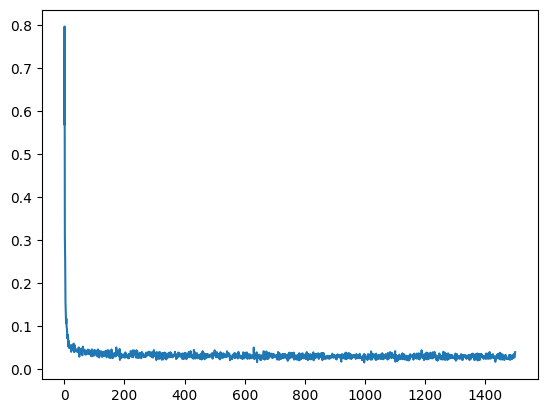

In [12]:
losses = []

model.train()
step = 0
num_train_steps = 1500
num_epoches = 10
HIGH = 14


t_grid = torch.linspace(1.0, 0.0, HIGH, device=DEVICE)      # [28]
r_grid = torch.linspace(1.0, float(HIGH), HIGH, device=DEVICE)  # [28]

for epoch in range(num_epoches):
    for images, _ in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(DEVICE)
        B = images.shape[0]

        x0 = images
        x1 = torch.randn_like(x0)

        idx = torch.randint(low=0, high=HIGH, size=(B,), device=DEVICE)

        # CHANGED: use the predefined schedules
        t = t_grid[idx]                 # shape [B]
        r = r_grid[idx].long()          # shape [B], integer ranks 1..28

        t_view = t.view(-1, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1

        x0_hat = model(xt, t * 1000)

        x0_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_i = x0[i:i+1]

            x0_r = fft_truncate(x0_i, ri)

            x0_lowrank.append(x0_r)

        x0_lowrank = torch.cat(x0_lowrank, dim=0)

        x0_hat_lowrank = []
        for i in range(B):
            ri = int(r[i].item())

            x0_hat_i = x0_hat[i:i+1]

            x0_hat_r = fft_truncate(x0_hat_i, ri)

            x0_hat_lowrank.append(x0_hat_r)

        x0_hat_lowrank = torch.cat(x0_hat_lowrank, dim=0)


        loss = F.mse_loss(x0_hat_lowrank, x0_lowrank)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step >= num_train_steps:
            break

    if step >= num_train_steps:
        break


plt.plot(losses)
plt.show()


In [13]:
@torch.no_grad()
def sample_images_x0(model, n_samples=16, steps=100, device=DEVICE):
    model.eval()

    # Start from pure noise at t = 1
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Time grid: 1 -> 0
    ts = torch.linspace(1.0, 1e-3, steps + 1, device=device)

    for i in range(steps):
        t = ts[i]
        t_next = ts[i + 1]
        dt = t - t_next

        t_batch = torch.full((n_samples,), t, device=device)

        # Model predicts x0_hat from current xt
        x0_hat = model(x, t_batch * 1000)

        # Implied forward velocity from x_t = (1-t)x0 + t x1
        # v_hat = dx/dt = (x_t - x0_hat) / t
        v_hat = (x - x0_hat) / (t_batch.view(-1, 1, 1, 1) + 1e-6)

        # Euler step backward in time
        x = x - dt * v_hat

    return x

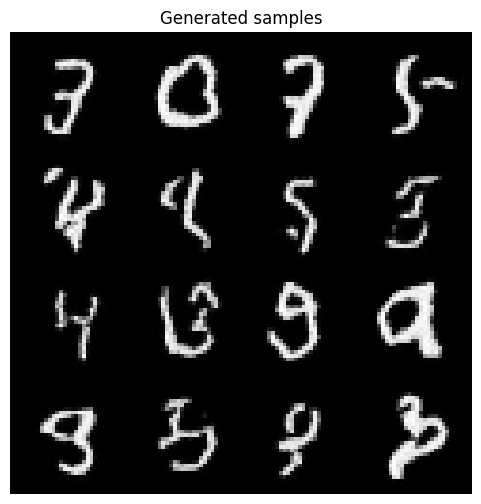

In [16]:
samples = sample_images_x0(model, n_samples=16, steps=28, device=DEVICE)

# map from [-1, 1] to [0, 1] for plotting
samples = samples.clamp(-1, 1)
samples = (samples + 1) / 2

grid = make_grid(samples, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated samples")
plt.show()

In [17]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'./MNIST/generate_fm_x0_lin_aligned_fft/{num_steps}/'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
                        
        with torch.no_grad():
            x_t = sample_images_x0(model, n_samples=batch_size, steps=num_steps)

        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

Generating and saving images: 100%|██████████| 10/10 [00:22<00:00,  2.23s/it]
